Initial price : $100.00
Mean final price : $108.53
Median final price : $106.27
5th percentile : $76.23
95th percentile : $147.92


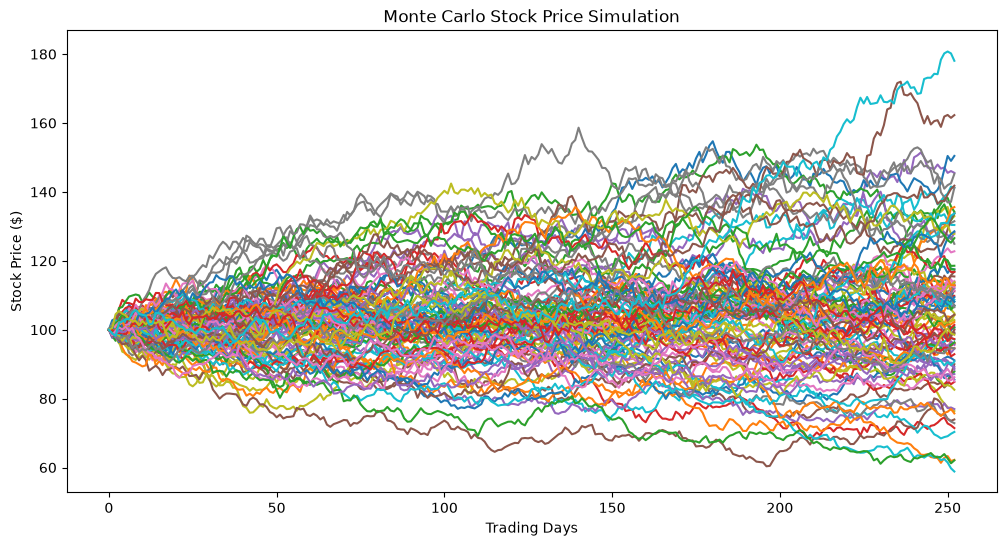

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# model parameters

S0 = 100
mu = 0.08
sigma = 0.20

T = 1.0
n_steps = 252
n_simulations = 10000

dt = T / n_steps

# random number generator

rng = np.random.default_rng(42)

# initialise price matrix

price = np.zeros((n_steps+1,n_simulations))

price[0] = S0

# Monte Carlo Simulation

for t in range(n_steps) : 
  z = rng.standard_normal(n_simulations)

  price[t+1] = price[t] * np.exp((mu - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * z)

final_price = price[n_steps]

# results 

print(f"Initial price : ${S0:.2f}")
print(f"Mean final price : ${np.mean(final_price):.2f}")
print(f"Median final price : ${np.median(final_price):.2f}")
print(f"5th percentile : ${np.percentile(final_price, 5):.2f}")
print(f"95th percentile : ${np.percentile(final_price, 95):.2f}")

probability_above_120 = np.mean(final_price > 120) 
probability_below_80 = np.mean(final_price < 80)

# plotting simmulated price paths

plt.figure(figsize=(12,6))
plt.plot(price[:, :100])
plt.title("Monte Carlo Stock Price Simulation")
plt.xlabel("Trading Days")
plt.ylabel("Stock Price ($)")
plt.show()
